# Welcome to lkdata!

In this notebook, we will cover the basic properties of lkdata, as well as examples of how to use the built-in functionality. 

The `lkdata` objects allow us to manipulate the data in a number of ways, including binning by time, slicing, folding, data aggregation and mathematical transformations. 

We start by introducing the data classes using simulated data in sections 1 and 2. If you are interested in how the lkdata structure can be applied to real data, you can check out the [example notebook](./nb2_lkdata_example.ipynb). 


# 1 - Handling 1-Dimensional timeseries data

In the simplest case, with only time and data, there are few benefits over simply using pandas, but astronomical data is more complicated. At the very least we should like to be able to handle uncertainties with numerical data.

Before we begin, let's create a random dataset to learn about the structure.

In [ ]:
# Import all of the packages we will use throughout this notebook
import numpy as np
import matplotlib.pyplot as plt
import lkdata as lk

print(lk.__path__)

['/Users/dkgiles/Repositories/secret/src/lkdata']
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [194]:
# Generate some random times.
times = np.append(np.linspace(0, 24, 120), np.linspace(26, 40, 120))

# Generate some random data
data = np.random.standard_normal(len(times))

# Generate some errors
data_err = np.abs(data) * 0.1

### 1.1 DataSeries

The `DataSeries` object can be used to represent any series of numerical data associated with time. In the `lkdata` ecosystem, data are unitless python data types, but metadata for units can be stored and accessed quite easily.

In [195]:
# Create a DataSeries object with data, associated uncertainties, and time information, and extra 'metadata'
series = lk.DataSeries(
    data=data,
    uncertainty=data_err,
    time_indices={"time": times, "offset_time": times + 200},
    extra_metadata="This is my first DataSeries",
    time_units="days",
)
series

time_index  time       offset_time
0           0.000000   200.000000    -1.883433
1           0.201681   200.201681     0.345099
2           0.403361   200.403361     0.316066
3           0.605042   200.605042     1.323777
4           0.806723   200.806723    -1.267770
                                        ...   
235         39.529412  239.529412     0.272923
236         39.647059  239.647059     1.706922
237         39.764706  239.764706    -0.450652
238         39.882353  239.882353     0.742590
239         40.000000  240.000000    -0.135223
Length: 240, dtype: float64


📉 DataSeries (240,), Uncertainty: True

Great, we've initialized our first DataSeries! The representation of the object is very similar to a pandas DataFrame. The above cell shows that this is a DataSeries object with a length of 120 with non-zero uncertainties. A default ranged time_index has been created and all provided time columns are included as a [MultiIndex](https://pandas.pydata.org/docs/user_guide/advanced.html). Metadata are not shown in the default [repr](https://docs.python.org/3/library/functions.html#repr), but you can see more information using describe_series(), as shown below.

In [196]:
series.describe_series()

📉 DataSeries (240,), Uncertainty: True (240,) (ntime)


Time indices available: ['time_index', 'time', 'offset_time']
	time_index     :	[  0   1 ... 238 239]
	time           :	[ 0.          0.20168067 ... 39.88235294 40.        ]
	offset_time    :	[200.         200.20168067 ... 239.88235294 240.        ]

User defined attributes accessible via `object.key`
	extra_metadata :	This is my first DataSeries
	time_units     :	days


You can access any of the properties, including the different time arrays and metadata, by using their keynames.

In [197]:
series.offset_time[:10]

array([200.        , 200.20168067, 200.40336134, 200.60504202,
       200.80672269, 201.00840336, 201.21008403, 201.41176471,
       201.61344538, 201.81512605])

In [198]:
series.time_units

'days'

### 1.2 BoolSeries and BitwiseSeries

Creating a BoolSeries or a BitwiseSeries is very similar to creating a DataSeries. The main difference is the data type.

We will create one my making a boolean array based on the random data generated in [Section 1.1](#11-dataseries), selecting out only positive data as an example.

In [199]:
# Create a boolean array based on the data values
mask = data > 0
mask

array([False,  True,  True,  True, False, False, False, False, False,
        True, False, False, False,  True,  True, False, False,  True,
       False,  True, False,  True,  True, False,  True, False, False,
       False,  True, False,  True, False,  True, False,  True, False,
       False,  True, False,  True,  True, False, False, False,  True,
       False,  True,  True, False,  True, False, False,  True,  True,
        True,  True, False,  True, False,  True,  True,  True,  True,
        True, False, False, False, False,  True, False, False,  True,
        True,  True,  True,  True, False,  True, False,  True, False,
        True,  True, False,  True, False,  True,  True,  True,  True,
       False, False,  True,  True,  True, False,  True, False, False,
       False,  True, False,  True, False, False,  True, False,  True,
        True,  True,  True,  True, False, False,  True,  True, False,
       False, False,  True, False, False, False,  True, False,  True,
        True,  True,

In [200]:
boolseries = lk.BoolSeries(
    data=mask,
    uncertainty=data_err,
    time_indices={"time": times},
)
boolseries.describe_series()

⚫️⚪️ BoolSeries (240,) (240,) (ntime)


Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 238 239]
	time        :	[ 0.          0.20168067 ... 39.88235294 40.        ]

User defined attributes accessible via `object.key`
	uncertainty :	[0.18834326 0.03450989 ... 0.07425901 0.01352227]


And just like that we have a `BoolSeries`!

In this case, we assigned an uncertainty value as we did for the `DataSeries`. However, the numerical uncertainties do not apply to boolean values so the uncertainty values are considered metadata, not true Uncertainty values. Modifying or slicing the BoolSeries with not apply to the given uncertainty as they are treated strictly as additional metadata.

`BitwiseSeries` was developed to handle the [TESS](https://outerspace.stsci.edu/display/TESS/2.0+-+Data+Product+Overview) and [Kepler/K2](https://archive.stsci.edu/files/live/sites/mast/files/home/missions-and-data/k2/_documents/MAST_Kepler_Archive_Manual_2020.pdf#page=18) quality masks. The quality flags are stored in a bitwise operation such that each flag is represented by a power of 2. A quality value of 3 would be composed of the flags 1 ($2^0$) and 2 ($2^1$). A quality value of 4 would only be the flag 4 ($2^2$).

In [202]:
flags = np.random.choice(16, size=len(times))
code_dict = {2**i: f"code {2**i}" for i in range(5)}
bitseries = lk.BitwiseSeries(
    flags,
    time_indices={"time": times},
    code_dict=code_dict,
    display_as="int",  # try "bitset" and "detailed"
)
bitseries

📗 BitwiseSeries (240,)

Note the additional keyword arguments `code_dict` and `display_as`. 

The `display_as` keyword can be "int", "bitset", or "detailed" (if a code dictionary is provided, otherwise it is the same as "bitset"). The "int" display shows the values as a combination of the powers of 2, as they would be given by TESS or Kepler. The "bitset" display shows the set of all included powers of 2.


Providing `code_dict` enables the detailed display, which could provide a description of the flags or other metadata to be associated with particular flags.

The values in a `BitSeries` are converted to a custom `BitSet` object, a `set` subclass which splits integer values into powers of 2 and enables bitwise logic and math.

In [172]:
from lkdata.bitset import BitSet

In [173]:
BitSet(10)

BitSet {2, 8}

In [174]:
BitSet(10) + 3

BitSet {1, 2, 8}

In [175]:
2 in BitSet(10)

True

### 1.3 Manipulating DataSeries data

In [203]:
# TODO - check when downsample allows specifying time bins

print(f"The series has shape {series.shape}")
downsampled_series = series.downsample(level="time")  # default 5 time steps
print(f"The downsampled series has shape {downsampled_series.shape}")
print(" ")
downsampled_series

The series has shape (240,)
The downsampled series has shape (24,)
 
time_index  time       offset_time  indices              
2.0         0.403361   200.403361   [0 1 2 3 4]             -1.166261
7.0         1.411765   201.411765   [5 6 7 8 9]             -2.620769
12.0        2.420168   202.420168   [10 11 12 13 14]         0.202684
17.0        3.428571   203.428571   [15 16 17 18 19]         0.695276
22.0        4.436975   204.436975   [20 21 22 23 24]         2.840556
27.0        5.445378   205.445378   [25 26 27 28 29]        -1.798542
32.0        6.453782   206.453782   [30 31 32 33 34]         0.147007
37.0        7.462185   207.462185   [35 36 37 38 39]        -1.165762
42.0        8.470588   208.470588   [40 41 42 43 44]        -1.632255
47.0        9.478992   209.478992   [45 46 47 48 49]        -0.108704
52.0        10.487395  210.487395   [50 51 52 53 54]         1.245539
57.0        11.495798  211.495798   [55 56 57 58 59]         0.766904
62.0        12.504202  212.504202

📉 DataSeries (24,), Uncertainty: True

In this case, the size of the time steps changed before and after the 'gap' in time. Downsample can handle gaps in time, but does expect uniform time steps when time data is available. In this case, only data before the gap is binned (you can see this by looking at the index values and length of downsampled_series from the cell above). 

You can force binning of the data by specifying level='time_index'. This forces downsample to use the index values rather than the time values themselves. The downside of this is that the bins before and after the gap have different effective exposure times.

In [204]:
downsampled_series = series.downsample(level="time_index")  # default 5 time_index steps
print(f"The series has shape {series.shape}")
print(f"The downsampled series has shape {downsampled_series.shape}")
downsampled_series

The series has shape (240,)
The downsampled series has shape (48,)
time_index  time       offset_time  indices              
2.0         0.403361   200.403361   [0 1 2 3 4]             -1.166261
7.0         1.411765   201.411765   [5 6 7 8 9]             -2.620769
12.0        2.420168   202.420168   [10 11 12 13 14]         0.202684
17.0        3.428571   203.428571   [15 16 17 18 19]         0.695276
22.0        4.436975   204.436975   [20 21 22 23 24]         2.840556
27.0        5.445378   205.445378   [25 26 27 28 29]        -1.798542
32.0        6.453782   206.453782   [30 31 32 33 34]         0.147007
37.0        7.462185   207.462185   [35 36 37 38 39]        -1.165762
42.0        8.470588   208.470588   [40 41 42 43 44]        -1.632255
47.0        9.478992   209.478992   [45 46 47 48 49]        -0.108704
52.0        10.487395  210.487395   [50 51 52 53 54]         1.245539
57.0        11.495798  211.495798   [55 56 57 58 59]         0.766904
62.0        12.504202  212.504202  

📉 DataSeries (48,), Uncertainty: True

#### 1.3.2 - slicing

DataSeries objects can be easily sliced in the same manner you [slice numpy arrays](https://numpy.org/doc/stable/user/absolute_beginners.html#indexing-and-slicing). In the example below we slice every other sample from the first 100 time steps in the DataSeries.

In [205]:
sliced_series = series[:100:2]
print(f"The series has shape {series.shape}")
print(f"The series after slicing has shape {sliced_series.shape}")
sliced_series

The series has shape (240,)
The series after slicing has shape (50,)
time_index  time       offset_time
0           0.000000   200.000000    -1.883433
2           0.403361   200.403361     0.316066
4           0.806723   200.806723    -1.267770
6           1.210084   201.210084    -0.854976
8           1.613445   201.613445    -0.649602
10          2.016807   202.016807    -0.987255
12          2.420168   202.420168    -0.505101
14          2.823529   202.823529     0.225253
16          3.226891   203.226891    -0.398671
18          3.630252   203.630252    -0.303542
20          4.033613   204.033613    -0.206824
22          4.436975   204.436975     0.422095
24          4.840336   204.840336     1.131901
26          5.243697   205.243697    -0.867007
28          5.647059   205.647059     0.134578
30          6.050420   206.050420     0.352895
32          6.453782   206.453782     1.391177
34          6.857143   206.857143     0.012118
36          7.260504   207.260504    -0.793473
38 

📉 DataSeries (50,), Uncertainty: True

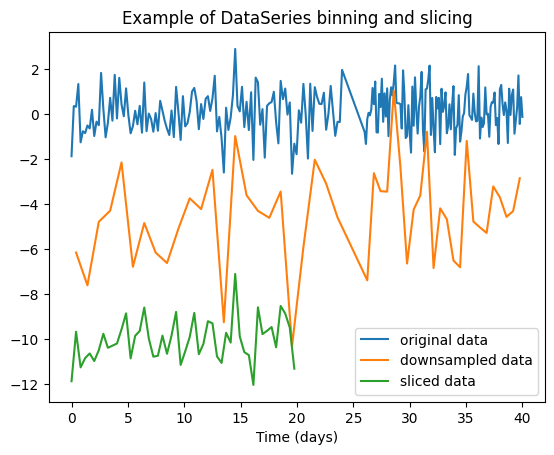

In [212]:
# Let's take a look at what these DataSeries look like
fig, ax = plt.subplots(1)
ax.set_title("Example of DataSeries binning and slicing")
ax.plot(series.time, series.data, label="original data")
# Note we are artificially adding a y-offset to the data for clarity
ax.plot(
    downsampled_series.time, downsampled_series.data - 5, label="downsampled data"
)  # bin 5 datapoints
ax.plot(
    sliced_series.time, sliced_series.data - 10, label="sliced data"
)  # First 100 time steps, keeping every other step
ax.set_xlabel(f"Time ({series.time_units})")
ax.legend()
plt.show()

# 2 - Handling timeseries for 2-Dimensional data, data cubes

Now let's take a look at timseries of 2-D images. lkdata handles this type of data with the DataCube class. For TESS, Kepler, and K2 data, this would be the data structure used to describe image timeseries, such as TPFs and FFI data. The DataCube structure allows us to manipulate this data in a number of ways, including binning (either spatially or by time), slicing, folding, or doing mathematical operations. We will look at these in more detail in the following cells. 

Before we begin, let's create a random dataset to learn about the structure. We will apply this to real data in section 3 below. 


## 2.1 creating a DataCube

In [216]:
# Generate some random times.
times = np.linspace(0, 24, 120)

# Generate some random data
data = np.random.randn(len(times), 5, 7)

# Generate some errors
data_err = np.abs(data) * 0.1

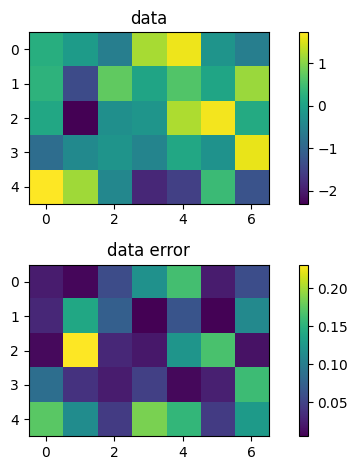

In [239]:
# print out the first 'image'
fig, ax = plt.subplots(2, tight_layout=True)
fig.colorbar(ax[0].imshow(data[0]))
fig.colorbar(ax[1].imshow(data_err[0]))
ax[0].set_title("data")
ax[1].set_title("data error");

In [240]:
print(times.shape, data.shape, data_err.shape)

(120,) (120, 5, 7) (120, 5, 7)


We have now generated the data needed to make a DataCube. In this example, we are making a timeseries with 120 time steps. We also have a 2-dimentional data product for each of these times steps. We can now put this information into our DataCube object. 

In [242]:
cube = lk.DataCube(
    data=data,
    uncertainty=data_err,
    time_indices={"time": times},
    meta="My first DataCube",
)

In [243]:
cube

📘 DataCube (120, 5, 7), Uncertainty: True

Great! You can see that when we call the cube object, we get a basic summary of the contents. This tells us the shape of the cube and whether there are uncertainties associated with the data. It also shows a visualization of the data contained in the first time step.

We can get more information about the data contained in the Cube by calling describe_cube()

In [244]:
cube.describe_cube()

📘 DataCube (120, 5, 7), Uncertainty: True (ntime, nrow, ncol)
pd.DataFrame shape: (120, 35)


Time indices available: ['time_index', 'time']
	time_index  :	[  0   1 ... 118 119]
	time        :	[ 0.          0.20168067 ... 23.79831933 24.        ]

Number of unique 'series': 35

Row names: ['row']
	row         :	[0 0 ... 4 4]

Column names: ['col']
	col         :	[0 1 ... 5 6]

User defined attributes accessible via `object.key`
(displaying only unique values)
	meta        :	My first DataCube


## 2.2 Manipulating DataCubes - a bit like numpy, a bit like pandas

As with the DataSeries, you can manipulate the data cubes by slicing or binning (either temporally or spatially) the data. We demonstrate these functions in the cells below. 

### 2.2.1 Aggregating like pandas

`lkdata` objects inherit a lot of functionality from pandas objects. For example, you can call mean/median/min/max functions specifying the axis as you would a pandas dataframe. 

Aggregation methods, like `mean` and `median` operate on the time or space axes. Axis 0 being time, and axis 1 being space (both row and column).

Notice in the case below, you get a tuple as a result. When aggregating over time, we are no longer dealing with time series and the returned product is either a tuple containing arrays for data and errors, or just the array for data.

In [260]:
data_mean, error_mean = cube.mean(axis=0)
data_mean.shape

(5, 7)

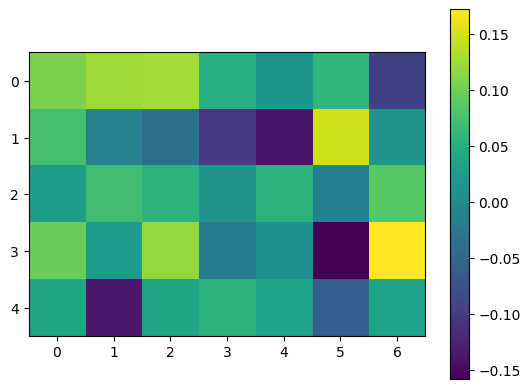

In [264]:
plt.colorbar(plt.imshow(data_mean));

Aggregating over space compresses the data and a `Series` is returned.

In [265]:
cube.mean(axis=1)

time_index  time     
0           0.000000     0.032296
1           0.201681     0.091823
2           0.403361    -0.065295
3           0.605042     0.262185
4           0.806723     0.061796
                           ...   
115         23.193277   -0.238956
116         23.394958    0.052371
117         23.596639    0.059914
118         23.798319    0.207335
119         24.000000   -0.288737
Length: 120, dtype: float64


📉 DataSeries (120,), Uncertainty: True

#### 2.2.2 - Slicing like numpy
Now that we have our DataCube set up, we can start manipulating the data as we did for DataSeries objects. 

For example, what if we want only 1 out of every 10 time steps?

In [25]:
sub_cube = cube[::10, :, :]  # Slice in the time step dimension
sub_cube

📘 DataCube (12, 5, 7), Uncertainty: True

Or only the last time step?

In [30]:
cube[-1, :, :]

📘 DataCube (1, 5, 7), Uncertainty: True

Or to keep all timesteps for a specific subset of pixels?

In [27]:
sub_cube = cube[:, 1:4, 2:5]  # Cut out a selection of pixels
sub_cube

📘 DataCube (120, 3, 3), Uncertainty: True

### 2.3 Downsampling (binning) by time

Instead of slicing, we may instead want to bin the data in the time dimension. This has the effect of taking the *sum* of each 'pixel' over the specified number of time steps. Note that the uncertaintaies are automatically added in quadrature. 

As with the DataSeries in Section 1.3.1, you can specify the specific value in the time index you want to include. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [ ]:
# Downsample every 5 time steps. If nframes is unspecified, 5 is the default value.
timebin_cube = cube.downsample(nframes=5, level="time")
timebin_cube

📘 DataCube (24, 5, 7), Uncertainty: True

In [ ]:
# Verify that the uncertainties were added in quadrature
print(cube.uncertainty[0:5, 0, 0])  # first 5 uncertainty values for pixel (0,0)
print(
    timebin_cube.uncertainty[0, 0, 0]
)  # first binned uncertainty value for pixel (0,0)

np.sqrt(np.sum(cube.uncertainty[0:5, 0, 0].array ** 2))

Uncertainty([0.02647953, 0.16005953, 0.03263863, 0.02991651, 0.14245798])
Uncertainty(0.22039685)


0.22039685128543998

### 2.4 Downsampling (binning) spatially

You are also allowed to spatially downsample DataCube objects. This would create the *sum* of pixels. If you specify "factor={integer}", it will use the same downsample size for column and row. For unevenly sized bins, you are able to sepcify col_factor/row_factor. Column/rows at the edge that do not "fill up" a new bin are discarded. In the case below, this would mean that column 6 and row 4 are discarded in the resulting DataCube object. 

TODO: enable downsample command to accept mean or median (default median is fine). 

In [ ]:
spacebin_cube = cube.spatial_downsample(factor=2)
spacebin_cube

📘 DataCube (120, 2, 3), Uncertainty: True

In [ ]:
spacebin_cube = cube.spatial_downsample(col_factor=3, row_factor=2)
spacebin_cube

📘 DataCube (120, 2, 2), Uncertainty: True

# 3 - SeriesCollections

This looks great when slicing contiguous pixels, as we did in the cell above. But what happens when you extract non-contiguous pixels?

In [248]:
sub_cube = cube[:, ::2, ::2]  # Cut out all time steps for every other pixel
sub_cube.describe_collection()

🟦 SeriesCollection (120, 12), Uncertainty: True (ntime, nseries)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 3, 4))

Time indices available: ['time_index', 'time']
	time_index :	[  0   1 ... 118 119]
	time       :	[ 0.          0.20168067 ... 23.79831933 24.        ]

Row names: ['row']
	row        :	[0 0 0 0 2 2 2 2 4 4 4 4]

Column names: ['col']
	col        :	[0 2 4 6 0 2 4 6 0 2 4 6]

User defined attributes accessible via `object.key`
(displaying only unique values)
	meta       :	My first DataCube


This looks a little bit different. Since we no longer have contiguous blocks of pixels, this now returns the underlying pandas data frame contianing information on each pixel. Note that in this case you can no longer treat the object as a DataCube with the same functionality as before. Instead the data is handled by the third class, a `SeriesCollection`, which as the name implies is a collection of individual light curves that we want to treat as a cohesive unit, but are not spatially tied together. 

You are also able to generate your own DataSeriesCollections, as shown in the cell below. 

In [ ]:
# Generate some random data for 10 'timeseries' with 120 time steps
data = np.random.randn(120, 10)

# Generate some errors
data_err = np.abs(data) * 0.1

collection = lk.DataSeriesCollection(
    data=data,
    uncertainty=data_err,
)

collection

series,0,1,2,3,4,5,6,7,8,9
time_index,,,,,,,,,,
0,0.303262,-0.304111,-0.700656,-0.674802,0.929585,0.606744,0.379289,-0.994772,-1.026128,-1.912490
1,1.003666,-1.699318,-0.868872,0.562635,0.514062,0.764792,0.139914,-0.135869,-1.391848,-0.217784
2,-1.314866,1.531951,-1.835623,0.956858,-0.501495,-0.245966,-0.976038,-0.946979,-2.579951,-1.120077
3,0.710594,0.832803,0.825384,0.992744,-0.660333,-0.449797,0.084152,-1.303170,-0.848368,-0.671397
4,0.372796,0.967785,-0.355266,-0.545602,-1.118313,-0.548186,-0.074098,-1.082219,0.988382,1.170033
...,...,...,...,...,...,...,...,...,...,...
115,-1.514011,-0.217158,-0.114916,0.161396,-1.170954,0.568582,-1.734276,2.067972,0.443011,0.547151
116,0.353244,0.692143,-0.079687,2.100479,-0.000320,-0.171332,0.048143,-0.135429,0.092319,1.293307
117,0.335156,-1.984760,0.363101,-1.282371,-0.170936,-0.625005,1.075233,-0.117476,1.143901,2.015450


In [ ]:
collection.describe_collection()

🟦 SeriesCollection (120, 10), Uncertainty: True (ntime, nseries)

Uncertainty:
	uncertainty	:	Uncertainty(np.ndarray(120, 10))

Time indices available: ['time_index']
	time_index :	[  0   1 ... 118 119]



# Conclusion

lkdata provides a way to quickly manipulate timeseries-like data. As lkdata is built on pandas DataFrames, transformations such as slicing and binning are easily (and quickly) accomplished. In addition, pandas provides a stable and well-developed backbone to build upon. 

This tutorial covered the basic features of lkdata, including the types of data products available as well as the types of manipulations you can do with that data. It also gave an introduction to how this can be done using real timeseries data from TESS. These examples serve as building blocks to construct larger and more powerful DataSets. 

The next tutorial puts these concepts into practice using data from the TESS mission. It also extends these concepts by introducing the DataSet class, which bundles any number of Series, Collections, or Cubes into one product for swift handling.